In [2]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d

import os
import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('..')
sys.path.append('../GP_regr')
import plot_settings
import importlib
#import multi_exp_log
import SR_lib

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Importing data

In [3]:
RUN_ID = 'test3'
SAVE  = True
SELECTION = 'best'
DT = 1
Q0 = 17921.57581 
ITS = int(2e1)

# check if run_id exists, if not create it
if os.path.exists(f'saved_sr_models/{RUN_ID}/model_UE_{RUN_ID}.csv'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')

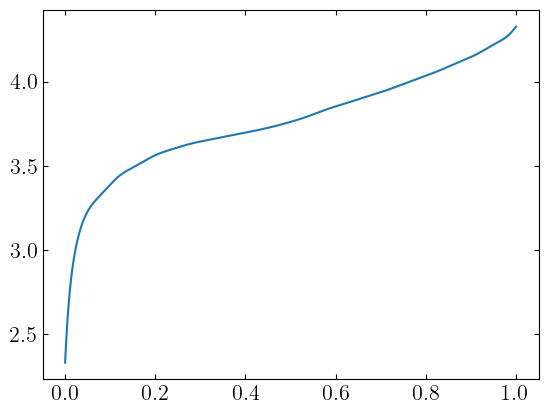

In [4]:
soc = np.linspace(0,1.0,int(1e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
#t = np.linspace(0,3600,int(1e4))
plt.plot(soc, Ue)

In [5]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

# $U_{eq} = f_U(\mathrm{SOC})$

Variable names for element Ue: ['soc']
Running symbolic regression for element Ue with run_id Ueq_test3...
Settings: iterations=20, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.09615141
Equation: 3.7617424

Model 1: Complexity=3, Loss=0.010167408
Equation: soc - -3.2612138

Model 2: Complexity=4, Loss=0.009438374
Equation: sqrt(soc) + 3.0918586

Model 3: Complexity=6, Loss=0.005064149
Equation: sqrt(soc * 1.629605) - -2.9117014

Model 4: Complexity=8, Loss=0.004071643
Equation: ((soc / 0.18090998) ^ 0.30042374) + 2.4728346

Model 5: Complexity=9, Loss=0.0038995533
Equation: tan(soc ^ 0.2248503) + 2.653206

Model 6: Complexity=10, Loss=0.0038705817
Equation: sqrt(sqrt(tan(soc)) + soc) + 2.6863763

Model 7: Complexity=11, Loss=0.0013588446
Equation: ((soc ^ 0.065235436) + cube(soc * 0.44257548)) * 3.918515

Model 8: Complexity=15, Loss=0.0011395679
Equation: log(square((square(soc) - (0.6149473 / (sqrt(soc) + 0.19701007))) + 4.6220136)) + 0.9387183

Model 9: Complexity=16, Loss=0.0010549258
Equation: log(square((square(soc) - (sqrt(0.3876743) / (sqrt(soc) + 0.19701007))) + 4.6220136)) + 0.9387183

Model 10: Complexity=17, Loss=0.00

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: log(soc**2 + 6.8059616 - 0.3839748/(soc**3*soc**(3*soc) - 0.7250107*soc**2 + sqrt(2*soc + 0.022536645)))**2 + 0.1964871
Loss: 0.00010635557
Best model complexity: 30


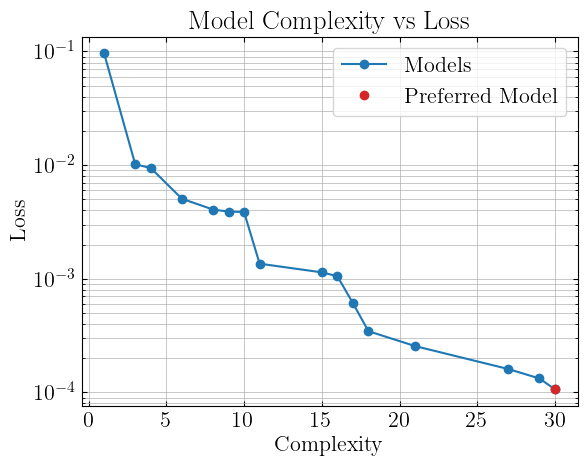

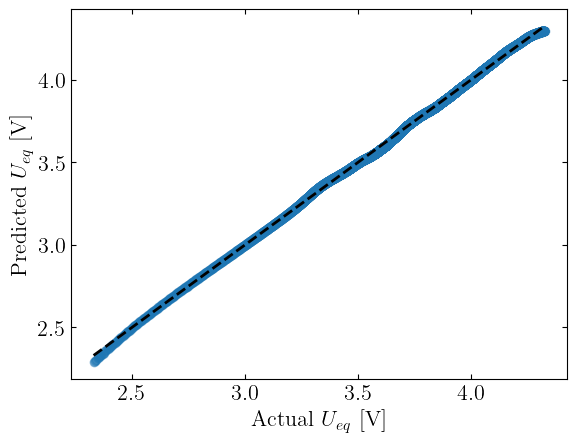

In [6]:
import_reload()
model_Ue = SR_lib.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'Ueq_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'Ue')
df_model_Ue = model_Ue.equations_
SR_lib.print_models(df_model_Ue)
SR_lib.print_best_model(model_Ue)
SR_lib.pareto_plot(model_Ue)
SR_lib.parity_plot_Ue(model_Ue, Y_train, X_train, colors=colors, data_set='train')

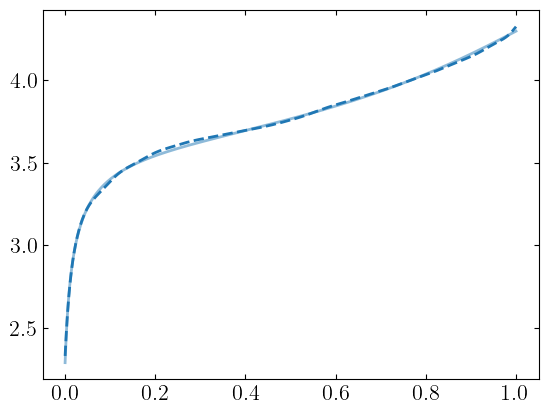

In [7]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0], alpha = 0.5, label = 'SR fit', lw = 2)
plt.plot(soc, Ue, color = colors[0],ls = '--', lw = 2, label = 'GP fit')

In [8]:
if SAVE:
    SR_lib.save_expressions(df_model_Ue,  f'Ue_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_Ue.get_best(), f'Ue_best_{RUN_ID}', run_id = RUN_ID)
    
    #save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #save_expressions(df_model_C1, f'C1_{RUN_ID}')